### Quantify the performance of parameters that determine orientation
C1: (real direction angle - The angle of Mode II)/real direction angle

C2: (Peak amplitude of Pitch-Peak amplitude of Roll)/ Peak amplitude of Pitch

C3: (Angle that maximizes C2 - real direction angle)/ real direction angle \n

C1

In [1]:
# imports
import os
import sys

# Get the directory of the current file
current_dir = os.path.dirname(os.path.realpath('__file__'))

# Get the parent directory
parent_dir = os.path.dirname(current_dir)
# Add the current directory and parent directory to the system path
sys.path.insert(0, current_dir)
sys.path.insert(0, parent_dir)

import numpy as np              # Python's standard numerical library
import matplotlib.pyplot as plt # Python's scientific visualization library
import importlib
from EMA_functions import *
from DIC_functions import *
import glob
import ast
from sdypy import EMA
import pickle as pkl
import matplotlib.cm as cm
import matplotlib.colors as col
import matplotlib.gridspec as gridspec
df_file_description = pd.read_csv('K:/My Drive/PHD/HSC/file_descriptions_wEMA.csv')
df_file_description = df_file_description.loc[:, ~df_file_description.columns.str.startswith('Unnamed')]



# List all files
files = glob.glob('D:/thijsmas/HSC/**/*.cihx', recursive=True)

D_in = 40
D_out = 100
nut_wh = (15, 60)
n_modes = 8
n_peak_modes = 4

required_parameters = [ 'id0_cam',
                        'id0_for',
                        'double_tap',
                        'smooth_lim',
                        'max_drift',
                        'max_end_drift', 
                        'peak_n', 
                        'peak_F', 
                        'peak_F_threshold', 
                        'shift',
                        'test_number', 
                        'd_lim', 
                        'prey_ij_d', 
                        'prey_ij', 
                        'spider_ij_d', 
                        'spider_ij',
                        'max_t_diff']


double_tap = False
taut_loose = 'Loose'
impact_pluck = 'Impact'
mass = True
df_filtered = df_file_description[(df_file_description['taut/loose'] == taut_loose) &
                                   (df_file_description['impact/pluck'] == impact_pluck) &
                                   (df_file_description['double_tap'] == double_tap) &
                                   (df_file_description['mass'] == mass)]


In [2]:
len(df_file_description)

219

In [3]:
from scipy.optimize import curve_fit
import numpy as np

D_in = 50
D_out = 100
nut_wh = (10, 60)
account_for_distortion = True
n_terms = 5  # Adjust as needed for desired smoothness

# df_filtered = df_filtered[df_filtered['cue1'] >0.3]
# df_filtered['cue1']
df_filtered.columns

Index(['filename', 'path', 'ecc', 'loc', 'mass', 'taut/loose', 'impact/pluck',
       'version', 'n_frames', 'fps', 'Oversatured pixels',
       'Undersatured pixels', 'prey_ij', 'spider_ij', 'peak_n', 'nut_idx',
       'd_lim', 'smooth_lim', 'max_drift', 'max_end_drift', 'lower', 'upper',
       'pol_order_high', 'added_damping', 'near_zero_threshold',
       'approximate_height', 'peak_F', 'peak_F_threshold', 'shift',
       'test_number', 'higher', 'spider_ij_d', 'prey_ij_d', 'id0_cam',
       'id0_for', 'double_tap', 'root', 'path2', 'max_t_diff', 'max_d_diff',
       'cue1', 'cue2', 'cue3', 'nat_freq', 'nat_xi', 'meanA', 'web', 'rev',
       'new', 'freq', 'A', 'main_modes'],
      dtype='object')

In [4]:
for col in ['freq', 'A']:
    df_file_description[col] = [[] for _ in range(len(df_file_description))]

df_file_description['freq']

0      []
1      []
2      []
3      []
4      []
       ..
214    []
215    []
216    []
217    []
218    []
Name: freq, Length: 219, dtype: object

In [5]:
# for index, row in df_filtered.iterrows():
#     root = row['root']
#     name_video = row['filename']
#     if root == 'None' or pd.isna(root):
#         df_file_description.loc[df_file_description['filename'] == name_video, 'rev'] = None
#         df_file_description.loc[df_file_description['filename'] == name_video, 'web'] = None
#         df_file_description.loc[df_file_description['filename'] == name_video, 'new'] = None
#         continue
#     print(f"Root: {root}")  # Print the first 40 characters of the root
#     char_after_web = root[:40].split('web')[1][0] if 'web' in root else None
#     print(f"Character after 'web': {char_after_web}")
#     char_after_rev = root[:40].split('rev')[1][0] if 'rev' in root else None
#     print(f"Character after 'rev': {char_after_rev}")
#     char_after_new = root.split('new')[1][0] if 'new' in root else None
#     print(f"Character after 'new': {char_after_new}")

#     if char_after_web is not None:
#         df_file_description.loc[df_file_description['filename'] == name_video, 'web'] = char_after_web
#     else:
#         df_file_description.loc[df_file_description['filename'] == name_video, 'web'] = '5'
#     if char_after_rev is not None:
#         df_file_description.loc[df_file_description['filename'] == name_video, 'rev'] = char_after_rev
#     else:
#         df_file_description.loc[df_file_description['filename'] == name_video, 'rev'] = '5'
#     if char_after_new is not None:
#         if char_after_new == '_':
#             char_after_new = '1'
#         df_file_description.loc[df_file_description['filename'] == name_video, 'new'] = char_after_new
#     else:
#         df_file_description.loc[df_file_description['filename'] == name_video, 'new'] = '5'
# df_file_description.to_csv('F:/My Drive/PHD/HSC/file_descriptions_wEMA.csv', index=False)

In [6]:
# from itertools import chain
# ecc = 2.0
# df_temp = df_filtered[df_filtered['ecc'] == ecc]

# rev_unique = set(chain.from_iterable(df_filtered['rev'].dropna()))
# web_unique = set(chain.from_iterable(df_filtered['web'].dropna()))
# new_unique = set(chain.from_iterable(df_filtered['new'].dropna()))
# print("Unique values in 'rev' column:", rev_unique)
# print("Unique values in 'web' column:", web_unique)
# print("Unique values in 'new' column:", new_unique)

In [9]:
%matplotlib qt
for file_i, (name_video, path_video, root_video) in enumerate(zip(df_filtered['filename'], df_filtered['path2'], df_filtered['root'])):
    if pd.isna(path_video):
        print(f'Could not open {name_video}')
        continue
    df = df_file_description[df_file_description['filename'].isin([name_video])]
    try:
        peak_n = df['peak_n'].item()
        peak_F = df['peak_F'].item()
        peak_F_threshold = df['peak_F_threshold'].item()
        prey_ij = ast.literal_eval(df['prey_ij'].item())
        spider_ij = ast.literal_eval(df['spider_ij'].item())
        shift = ast.literal_eval(df['shift'].item())
        d_lim = df['d_lim'].item()
        test_number = df['test_number'].item()
        nut_idx = df['nut_idx'].item()
        smooth_lim = df['smooth_lim'].item()
        max_drift = df['max_drift'].item()
        max_end_drift = df['max_end_drift'].item()
    except:
        print(f'File {name_video} not found in file description')
        continue
    file_parameters, index = unpack_dataframe(df_filtered, name_video, required_parameters)
    if file_parameters is None:
        print(f'some items in {name_video} could not be unpacked')
        continue
    EMA_structure = EMA_Structure(name_video)
    EMA_structure.set_params(**file_parameters)
    if np.isnan(EMA_structure.id0_cam):
        print(f'{name_video} has no cam id')
        continue

    EMA_structure.set_params(FN0 = 41.2, reaction_time = 0.1) # FN0 from Lott: Prey localization in spider orb webs using modal vibration analysis. reaction_time from (Klärner and Barth1982)
    if EMA_structure.double_tap:
        print(f'{name_video} had a double impact')
        continue

    EMA_structure.open_impact_data()
    video = EMA_structure.open_video(add_extension = False)
    fps = video.reader.info['Record Rate(fps)']
    dt = 1/fps
                    
    DIC_structure = DIC_Structure(path_video)
    df = DIC_structure.list_test_data(test_range = range(1, 100), robostness_check = False)
    print(df)
    try:
        last_row = df.iloc[-1]  # Get the last row of the DataFrame
    except:
        print(f'File {name_video} not found in DIC data')
        continue
    
    EMA_structure.tp, EMA_structure.d = DIC_structure.join_results([EMA_structure.test_number])
    td = EMA_structure.d +  EMA_structure.tp.reshape(len(EMA_structure.tp),1,2)

    EMA_structure.initialize_signals()
    EMA_structure.initialize_displacement(idx='all', dir='xy')
    EMA_structure.nut_idx((EMA_structure.prey_ij[0] + EMA_structure.shift[0], EMA_structure.prey_ij[1] + EMA_structure.shift[1]), exclude_high_amplitude = True, d_lim = EMA_structure.d_lim)

    EMA_structure.process_signals(EMA_structure.id0_cam, EMA_structure.id0_for)

    EMA_structure.set_freq_properties(padding_ratio=1)
    EMA_structure.get_transfer_function(direction='y')

    smooth_signals = np.max(np.abs(np.diff(np.linalg.norm(EMA_structure.d, axis=2))), axis = 1) < EMA_structure.smooth_lim
    non_drifting = np.abs(np.mean(np.linalg.norm(EMA_structure.d[:,:-100], axis=2), axis=1) < EMA_structure.max_drift)
    non_drifting2 = np.abs(np.linalg.norm(EMA_structure.d[:,-1], axis=1)) < EMA_structure.max_end_drift
    EMA_structure.valid_tps = smooth_signals & non_drifting & non_drifting2 & EMA_structure.exclude_high_amplitude

    file_path_cam = os.path.join(root_video, f'{name_video}_cam_2.pkl')
    with open(file_path_cam, 'rb') as file:
        cam = pkl.load(file)
    idx = df_file_description.index[df_file_description['filename'] == name_video][0]
    df_file_description.at[idx, 'nat_freq'] = cam.nat_freq
    df_file_description.at[idx, 'nat_xi'] = cam.nat_xi
    df_file_description.at[idx, 'meanA'] = list(np.linalg.norm(np.abs(cam.A), axis=0))
    df_file_description.at[idx, 'freq'] = list(cam.freq)
    df_file_description.at[idx, 'A'] = list(np.average(np.abs(cam.frf), axis=0))

    fig, ax = plt.subplots(2, 2, figsize=(10, 10))
    C1_save, best_mode = EMA_structure.Cue1(cam, video,n_angles = 1001, initial_guess = None, n_terms = n_terms, ax_real = ax[0, 0], ax_imag = ax[0, 1])
    df_file_description.loc[df_file_description['filename'] == name_video, 'cue1'] = C1_save
    df_file_description.to_csv('F:/My Drive/PHD/HSC/file_descriptions_wEMA.csv', index=False)
    print(f'{name_video} has a C1 of {C1_save} with mode {best_mode}')
    if np.isnan(best_mode):
        fig.savefig(f'{root_video}/{name_video}_Cue1_Mode_{best_mode}.png')
        plt.close(fig)
        continue

    EMA_structure.plot_hub_modes(cam, fig, ax[1,0], ax[1,1], best_mode, video, D_in = D_in, D_out = D_out, nut_wh = nut_wh, account_for_distortion = True, normalize_colors = True)
    ax[0, 0].legend()
    ax[0, 1].legend()

    fig.savefig(f'{root_video}/{name_video}_Cue1_Mode_{best_mode}.png')
    plt.close(fig)
    

C:\Users\thijs\Documents\GitHub\pyidi\scripts\EMA_functions.py:116: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  self.impact_data = pkl.load(f)
C:\Users\thijs\Documents\GitHub\pyidi\scripts\EMA_functions.py:83: UserWarning: Video file not found. Check the file name and paths to check.
  warn.warn('Video file not found. Check the file name and paths to check.')


AttributeError: 'NoneType' object has no attribute 'reader'

### Box plots Cue 1 per level of eccentricity

C:\Users\thijs\AppData\Local\Temp\ipykernel_22496\2853122213.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cue1_ecc0 = np.array(df_filtered[(df_file_description['ecc'] == 0.0)]['cue1'])*180/np.pi
C:\Users\thijs\AppData\Local\Temp\ipykernel_22496\2853122213.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cue1_ecc1 = np.array(df_filtered[(df_file_description['ecc'] == 1.0)]['cue1'])*180/np.pi
C:\Users\thijs\AppData\Local\Temp\ipykernel_22496\2853122213.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cue1_ecc2 = np.array(df_filtered[(df_file_description['ecc'] == 2.0)]['cue1'])*180/np.pi


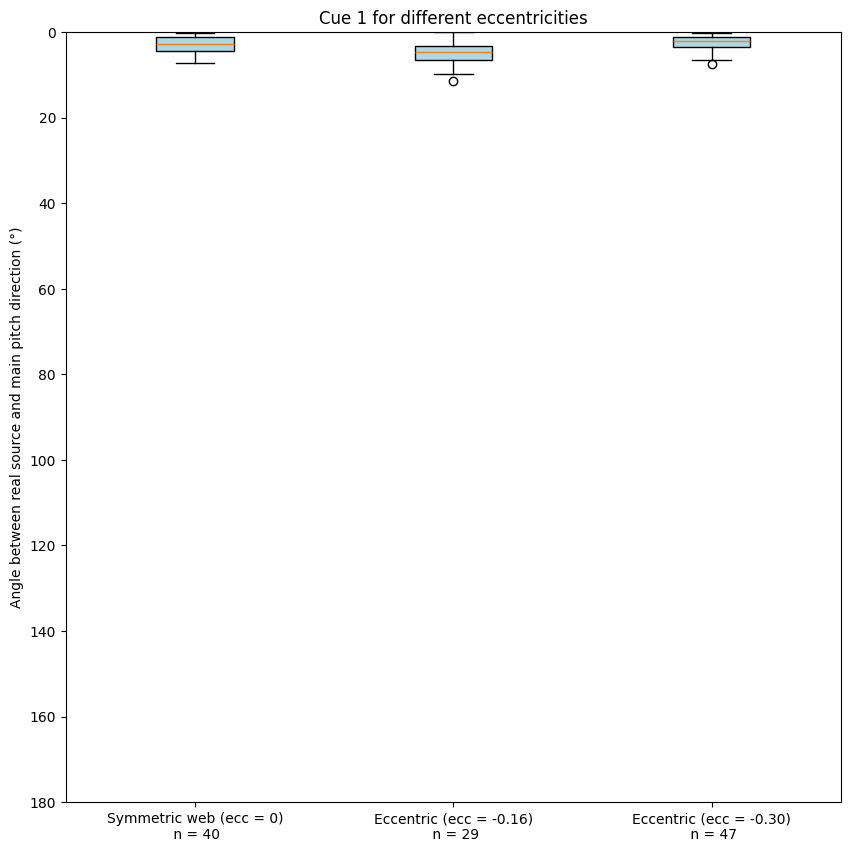

In [8]:
df_filtered = df_file_description[(df_file_description['taut/loose'] == taut_loose) &
                                   (df_file_description['impact/pluck'] == impact_pluck) &
                                   (df_file_description['double_tap'] == double_tap) &
                                   (df_file_description['mass'] == mass)]


cue1_ecc0 = np.array(df_filtered[(df_file_description['ecc'] == 0.0)]['cue1'])*180/np.pi
cue1_ecc1 = np.array(df_filtered[(df_file_description['ecc'] == 1.0)]['cue1'])*180/np.pi
cue1_ecc2 = np.array(df_filtered[(df_file_description['ecc'] == 2.0)]['cue1'])*180/np.pi

cue1 = [cue1_ecc0[~np.isnan(cue1_ecc0)], cue1_ecc1[~np.isnan(cue1_ecc1)], cue1_ecc2[~np.isnan(cue1_ecc2)]]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.boxplot(cue1, patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax.set_xticks([1, 2, 3])  # Set positions for x-axis ticks
ax.set_xticklabels([f'Symmetric web (ecc = 0)\n n = {len(cue1[0])}', f'Eccentric (ecc = -0.16)\n n = {len(cue1[1])}', f'Eccentric (ecc = -0.30)\n n = {len(cue1[2])}'])
ax.set_title('Cue 1 for different eccentricities')
ax.set_ylabel('Angle between real source and main pitch direction (°)')
ax.set_ylim(180, 0)
# ax.set_ylim(20, 0)

plt.show()

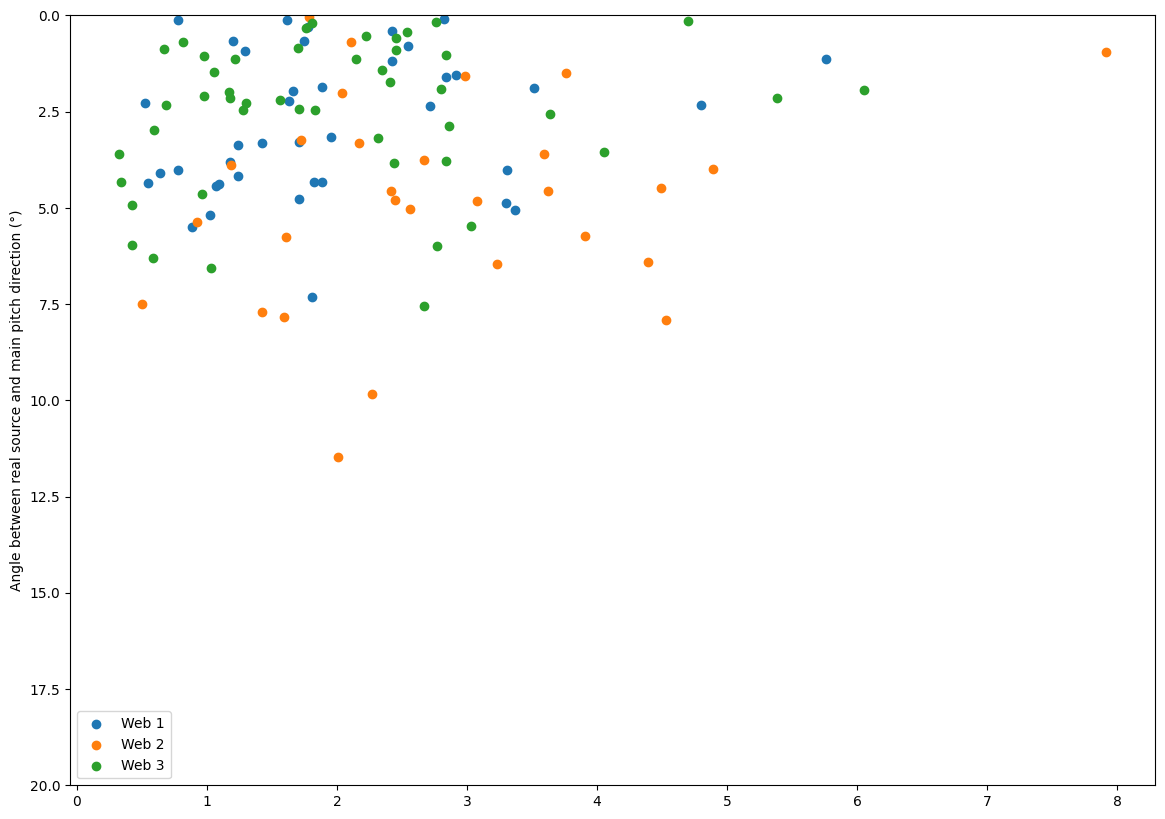

In [9]:
df_filtered = df_file_description[(df_file_description['taut/loose'] == taut_loose) &
                                   (df_file_description['impact/pluck'] == impact_pluck) &
                                   (df_file_description['double_tap'] == double_tap) &
                                   (df_file_description['mass'] == mass)]
cue1 = np.array(df_filtered['cue1'])*180/np.pi
Force_amp = np.array(pd.to_numeric(df_filtered['peak_F'], errors='coerce'))
mask = ~np.isnan(cue1) & ~np.isnan(Force_amp)

ecc0_mask = df_filtered['ecc'] == 0.0
ecc1_mask = df_filtered['ecc'] == 1.0
ecc2_mask = df_filtered['ecc'] == 2.0

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.scatter(Force_amp[(mask & ecc0_mask)], cue1[(mask & ecc0_mask)], label='Web 1')
ax.scatter(Force_amp[(mask & ecc1_mask)], cue1[(mask & ecc1_mask)], label='Web 2')
ax.scatter(Force_amp[(mask & ecc2_mask)], cue1[(mask & ecc2_mask)], label='Web 3')
ax.set_ylabel('Angle between real source and main pitch direction (°)')
ax.legend()
ax.set_ylim(20, 0)
plt.show()

In [11]:
cue2_ecc0 = np.array(df_filtered[(df_file_description['ecc'] == 0.0)]['cue2'])
cue2_ecc1 = np.array(df_filtered[(df_file_description['ecc'] == 1.0)]['cue2'])
cue2_ecc2 = np.array(df_filtered[(df_file_description['ecc'] == 2.0)]['cue2'])

cue2 = [cue2_ecc0[~np.isnan(cue2_ecc0)], cue2_ecc1[~np.isnan(cue2_ecc1)], cue2_ecc2[~np.isnan(cue2_ecc2)]]

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
fig.tight_layout()
ax.set_yscale('log')
ax.boxplot(cue2, patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax.set_xticks([1, 2, 3])  # Set positions for x-axis ticks
ax.set_xticklabels([f'Web 1\n n = {len(cue2[0])}', f'Web 2\n n = {len(cue2[1])}', f'Web 3\n n = {len(cue2[2])}'])
# ax.set_title('Ratio pitch roll')
ax.set_ylabel('Pitch Roll Ratio')
max_amp = np.max([np.max(cue2[0]) , np.max(cue2[1]), np.max(cue2[2])])*1.5
ax.plot([0.5,3.5], [1, 1], 'r--')
ax.set_ylim(1/max_amp, max_amp)
EMA_structure.root_simulations = r'I:/.shortcut-targets-by-id/1k1B8zPb3T8H7y6x0irFZnzzmfQPHMRPx/Illimited Lab Projects/Research Projects/Spiders/Simulations'
# fig.savefig(os.path.join(EMA_structure.root_simulations, 'Cues', 'cue2_boxplot.png'), dpi=300, bbox_inches='tight')
plt.show()
cue2

C:\Users\thijs\AppData\Local\Temp\ipykernel_16188\381936553.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cue2_ecc0 = np.array(df_filtered[(df_file_description['ecc'] == 0.0)]['cue2'])
C:\Users\thijs\AppData\Local\Temp\ipykernel_16188\381936553.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cue2_ecc1 = np.array(df_filtered[(df_file_description['ecc'] == 1.0)]['cue2'])
C:\Users\thijs\AppData\Local\Temp\ipykernel_16188\381936553.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cue2_ecc2 = np.array(df_filtered[(df_file_description['ecc'] == 2.0)]['cue2'])


[array([  9.45434293,   6.79786037,   4.87684417,  -4.39644032,
          6.87592426,   4.75806764,   6.10843417,   7.74652311,
          5.94939989,   5.8490883 ,   5.82085401,   6.17998939,
          3.93553675,   4.80008176,   4.34054811,   5.90196573,
          8.28014933,  -8.5009009 ,   8.74857058, -10.08374055,
          4.09606304,   6.15791137,  11.21069455,  10.33955706,
          5.78725783,  -7.42699722,  -2.33547807,   2.36357706,
         -3.37040024,  -3.45033628,   5.11731511,   4.72751933,
         -9.25841564,   5.95660406,   4.68251637,  -4.37453967,
         -9.63663212,  -5.6355909 ,   3.01305062,   4.09805187,
         -5.25056589,   5.35011625]),
 array([ 2.7446536 ,  3.46683893, -3.43205966, -3.41405297, -6.2658616 ,
        -7.78999647, -6.51058041, -6.27044208, -6.23802093, -3.27219899,
        11.58505554, -3.79809793, -3.88968044, -4.1731935 , -3.42340853,
        -6.68722829, -7.89763862, -8.90768332,  5.94030175,  3.55917766,
         3.33885209, -3.682195

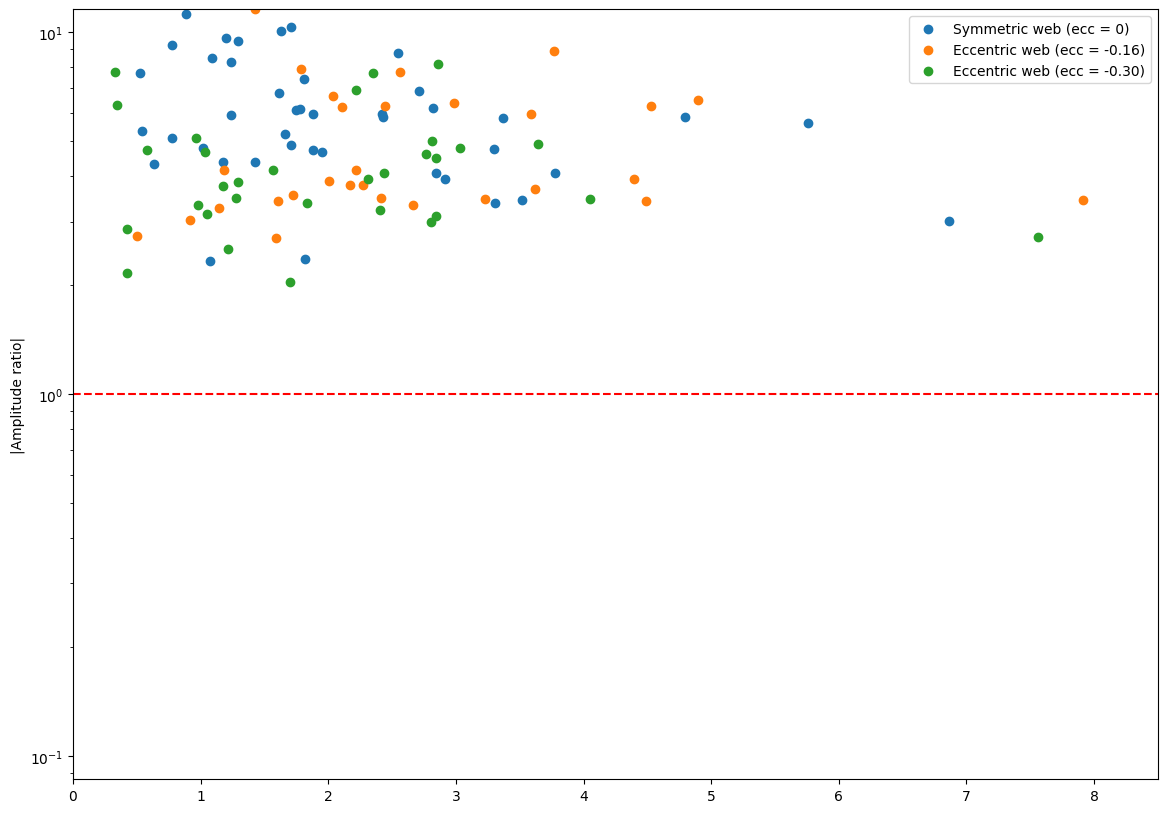

In [8]:
df_filtered = df_file_description[(df_file_description['taut/loose'] == taut_loose) &
                                   (df_file_description['impact/pluck'] == impact_pluck) &
                                   (df_file_description['double_tap'] == double_tap) &
                                   (df_file_description['mass'] == mass)]
cue2 = np.array(df_filtered['cue2'])
Force_amp = np.array(pd.to_numeric(df_filtered['peak_F'], errors='coerce'))
mask = ~np.isnan(cue2) & ~np.isnan(Force_amp)

ecc0_mask = df_filtered['ecc'] == 0.0
ecc1_mask = df_filtered['ecc'] == 1.0
ecc2_mask = df_filtered['ecc'] == 2.0

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
ax.set_yscale('log')
ax.scatter(Force_amp[(mask & ecc0_mask)], cue2[(mask & ecc0_mask)], label='Symmetric web (ecc = 0)')
ax.scatter(Force_amp[(mask & ecc1_mask)], cue2[(mask & ecc1_mask)], label='Eccentric web (ecc = -0.16)')
ax.scatter(Force_amp[(mask & ecc2_mask)], cue2[(mask & ecc2_mask)], label='Eccentric web (ecc = -0.30)')
ax.set_ylabel('|Amplitude ratio|')
# max_amp = np.max([np.max(cue2[0]) , np.max(cue2[1]), np.max(cue2[2])])
ax.plot([0,8.5], [1, 1], 'r--')
ax.set_ylim(1/max_amp, max_amp)
ax.set_xlim(0, 8.5)
ax.legend()
plt.show()

In [10]:
df_file_description

,filename,path,ecc,loc,mass,taut/loose,impact/pluck,version,n_frames,fps,...,cue3,nat_freq,nat_xi,meanA,web,rev,new,freq,A,main_modes
0,Full_web_ecc1_new_Floc1_nomass_v0_S01.cihx,H:\My Drive\PHD\HSC\ecc1\web0\no_mass\Full_web...,1.0,1.0,False,Loose,Impact,0.0,10000.0,8000.0,...,NaN,[],[],[],[],[],[],[],[],NaN
1,Full_web_ecc1_new_Floc8_nomass_v0_S01.cihx,H:\My Drive\PHD\HSC\ecc1\web0\no_mass\Full_web...,1.0,8.0,False,Loose,Impact,0.0,10000.0,8000.0,...,NaN,[],[],[],[],[],[],[],[],NaN
2,Full_web_ecc1_new_Floc2_nomass_v0_S01.cihx,H:\My Drive\PHD\HSC\ecc1\web0\no_mass\Full_web...,1.0,2.0,False,Loose,Impact,0.0,10000.0,8000.0,...,NaN,[],[],[],[],[],[],[],[],NaN
3,Full_web_ecc1_new_Floc9_nomass_v0_S01.cihx,H:\My Drive\PHD\HSC\ecc1\web0\no_mass\Full_web...,1.0,9.0,False,Loose,Impact,0.0,10100.0,8000.0,...,NaN,[],[],[],[],[],[],[],[],NaN
4,Full_web_ecc1_new_Floc9_nomass_v1_S01.cihx,H:\My Drive\PHD\HSC\ecc1\web0\no_mass\Full_web...,1.0,9.0,False,Loose,Impact,1.0,10000.0,8000.0,...,NaN,[],[],[],[],[],[],[],[],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,Full_web_ecc0_new2_Floc18_v1_S01.cihx,H:\My Drive\PHD\HSC\ecc0\web1\Full_web_ecc0_ne...,0.0,18.0,True,Loose,Impact,1.0,8000.0,8000.0,...,NaN,"[-0.0, 7.512941844020004, 14.9258430858324, 16...","[0.0, 0.014183000573798366, 0.0193444469425162...","[290179.1979843879, 425603.50732159475, 34225....",1,5,2,[],[],NaN
215,Full_web_ecc0_new2_Floc19_v0_S01.cihx,H:\My Drive\PHD\HSC\ecc0\web1\Full_web_ecc0_ne...,0.0,19.0,True,Loose,Impact,0.0,8000.0,8000.0,...,NaN,"[-0.0, 7.577623048267106, 8.786606929965252, 1...","[0.0, 0.013086347254045548, 0.0405675017888423...","[48021.44698958089, 219711.97152766725, 75560....",1,5,2,[],[],NaN
216,Full_web_ecc0_new2_Floc19_v1_S01.cihx,H:\My Drive\PHD\HSC\ecc0\web1\Full_web_ecc0_ne...,0.0,19.0,True,Loose,Impact,1.0,8000.0,8000.0,...,NaN,"[-0.0, 7.562428648378745, 16.216171454784085, ...","[0.0, 0.01651722817877627, 0.01019218416148741...","[100183.33438644756, 294363.35331878293, 39840...",1,5,2,[],[],NaN
217,Full_web_ecc0_new2_Floc5_v0_S01.cihx,H:\My Drive\PHD\HSC\ecc0\web1\Full_web_ecc0_ne...,0.0,5.0,True,Loose,Impact,0.0,8000.0,8000.0,...,NaN,"[-0.0, 7.663458570235849, 16.253846133711164, ...","[0.0, 0.01477943666430022, 0.00909898439106257...","[67693.28417509119, 411568.17170348536, 594046...",1,5,2,[],[],NaN


In [43]:
%matplotlib qt
def find_mode_index(freqs, amps, tolerance, target_freq):
    # Calculate the relative difference
    relative_diff = np.abs(freqs - target_freq) / target_freq

    # Find indices where the relative difference is within the tolerance
    candidates = np.where(relative_diff <= tolerance)[0]

    if len(candidates) > 0:
        # Get the index of the candidate with the highest amplitude
        max_amp_idx = candidates[np.argmax(amps[candidates])]
        return max_amp_idx
    else:
        return None  # or handle case where no match is found

df_filtered = df_file_description[(df_file_description['taut/loose'] == taut_loose) &
                                   (df_file_description['impact/pluck'] == impact_pluck) &
                                   (df_file_description['double_tap'] == double_tap) &
                                   (df_file_description['mass'] == mass)] # &
                                #    (df_file_description['web'] == '1') &
                                #    (df_file_description['new'] == '2')
                                #    ]

df_ecc0 = df_filtered[df_file_description['ecc'] == 0.0]
df_ecc1 = df_filtered[df_file_description['ecc'] == 1.0]
df_ecc2 = df_filtered[df_file_description['ecc'] == 2.0]
df_vec = [df_ecc0, df_ecc1, df_ecc2]
ecc_values = [0.0, -0.16, -0.30]
color_vec = ['blue', 'orange', 'green', 'purple', 'red', 'pink', 'brown', 'gray']
markers = ['o', 's', '^', 'D', 'x']

fn0 =  [7.248257854589026, 7.314985332263058, 7.223159300059347]
fn1 =  [fn0[0]*2, fn0[1]*2.2, fn0[2]*2.4]
fn2 =  [fn0[0]*3.4, fn0[1]*3.5, fn0[2]*3.47]
fn3 =  [fn0[1]*4.3, fn0[1]*4.2, fn0[2]*4.6]
fn4 =  [fn0[1]*5.0, fn0[1]*4.82, fn0[2]*5.0]
fn0_save = [[], [], []]

fig, ax = plt.subplots(3, 1, figsize=(10, 10))
tolerance = 0.05
for i,(df, ecc_v)in enumerate(zip(df_vec, ecc_values)):
    # ax[i].set_xlim(0.1, -0.4)
    ax[i].set_xlim(0, 5)
    ax[i].set_yscale('log')
    ax[i].set_xlabel('Omega (-)')
    ax[i].set_ylabel('Amp')
    for index, row in df.iterrows():
        nat_freq = np.array(row['nat_freq'])
        meanA = np.array(row['meanA'])
    
        if nat_freq == '[]':
            continue
        if len(nat_freq) == 0:
            continue
        meanA = np.abs(meanA[nat_freq > 0])
        nat_freq = nat_freq[nat_freq > 0]
        webi = eval(row['web'])
        revi = eval(row['rev'])
        newi = eval(row['new'])
        # nat_freqlow = nat_freq[nat_freq <20]
        # meanA_low = meanA[nat_freq <20]
        arg0 = find_mode_index(nat_freq, meanA, tolerance, fn0[i])
        arg1 = find_mode_index(nat_freq, meanA, tolerance, fn1[i])
        arg2 = find_mode_index(nat_freq, meanA, tolerance, fn2[i])
        arg3 = find_mode_index(nat_freq, meanA, tolerance, fn3[i])
        arg4 = find_mode_index(nat_freq, meanA, tolerance, fn4[i])

        # if arg0 is not None:
        #     ax[i].scatter(nat_freq[arg0]/nat_freq[arg0], meanA[arg0]/meanA[arg0], c='red', label='mode 1')
        #     fn0_save[i].append(nat_freq[arg0])
        # else:
        #     continue
        # if arg1 is not None:
        #     ax[i].scatter(nat_freq[arg1]/nat_freq[arg0], meanA[arg1]/meanA[arg0], c='blue', label='Prey mode')
        # if arg2 is not None:
        #     ax[i].scatter(nat_freq[arg2]/nat_freq[arg0], meanA[arg2]/meanA[arg0], c='orange', label='mode 2')
        # if arg3 is not None:
        #     ax[i].scatter(nat_freq[arg3]/nat_freq[arg0], meanA[arg3]/meanA[arg0], c='green', label='mode 3')
        # if arg4 is not None:
        #     ax[i].scatter(nat_freq[arg4]/nat_freq[arg0], meanA[arg4]/meanA[arg0], c='purple', label='mode 4')
        # if len(meanA_low) > 1:
        #     top_two_indices = np.argsort(meanA_low)[-2:]
        #     top_two_args = nat_freqlow[np.sort(top_two_indices)]
        #     idx = np.arange(len(top_two_args))
        #     ax[i].scatter(top_two_args, meanA_low[top_two_indices],c=idx, cmap='jet')

        # ax[i].scatter(ecc_v * np.ones_like(nat_freq), nat_freq, s = meanA/10, alpha=0.5)
        idx = np.arange(len(nat_freq))  # color by index
        # sc = ax[i].scatter(nat_freq/nat_freq[0], meanA/meanA[0], c=idx, cmap='jet', alpha=0.3)
        sc = ax[i].scatter(nat_freq/nat_freq[0], meanA/meanA[0], c=color_vec[revi],  marker=markers[webi + newi], label=f'rev {revi} web {webi} new {newi}')
        # sc = ax[i].scatter(nat_freq, meanA, c=color_vec[revi], marker=markers[webi + newi], label=f'rev {revi} web {webi} new {newi}')
fn0_save = [np.mean(fn0_save[0]), np.mean(fn0_save[1]), np.mean(fn0_save[2])]
handles, labels = ax[0].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax[0].legend(unique_labels.values(), unique_labels.keys())
handles, labels = ax[1].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax[1].legend(unique_labels.values(), unique_labels.keys())
handles, labels = ax[2].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax[2].legend(unique_labels.values(), unique_labels.keys())

print(fn0_save)

C:\Users\thijsmas\AppData\Local\Temp\ipykernel_48692\646810343.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ecc0 = df_filtered[df_file_description['ecc'] == 0.0]
C:\Users\thijsmas\AppData\Local\Temp\ipykernel_48692\646810343.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ecc1 = df_filtered[df_file_description['ecc'] == 1.0]
C:\Users\thijsmas\AppData\Local\Temp\ipykernel_48692\646810343.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ecc2 = df_filtered[df_file_description['ecc'] == 2.0]
C:\Users\thijsmas\AppData\Local\Temp\ipykernel_48692\646810343.py:51: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if nat_freq == '[]':


[nan, nan, nan]


c:\Users\thijsmas\AppData\Local\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\thijsmas\AppData\Local\anaconda3\Lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
plt.ion()  # Turn on interactive mode

fig, ax = plt.subplots()
fig.set_size_inches(16, 6)  # Set figure width to make it wide
ax.set_yscale('log')
ax.set_xlabel('Frequency (-)')
ax.set_ylabel('Amplitude (-)')

for index, row in df_filtered.iterrows():
    try:
        freq = np.array(row['freq'])
        frf  = np.array(row['A'])
        nat_freq = np.array(row['nat_freq'])
        meanA = np.array(row['meanA'])
    except:
        print(f'Not found')
        continue
    if nat_freq == '[]' or len(nat_freq) == 0:
        continue

    meanA = np.abs(meanA[nat_freq > 0])
    nat_freq = nat_freq[nat_freq > 0]
    if len(nat_freq) == 0:
        continue

    frf = np.abs(frf)

    ax.clear()
    ax.set_yscale('log')
    ax.set_xlabel('Frequency (-)')
    ax.set_ylabel('Amplitude (-)')
    ax.set_title(row['filename'])  # Show filename as title

    ax.plot(freq/nat_freq[0], frf/meanA[0], label='FRF')
    ax.plot(nat_freq/nat_freq[0], meanA/meanA[0], 'o', label='Poles')

    for i, nf in enumerate(nat_freq):
        x_val = nf / nat_freq[0]
        ax.axvline(x=x_val, color='gray', linestyle='--')
        ax.text(x_val, 0.95, f'{i}', rotation=90, verticalalignment='top', transform=ax.get_xaxis_transform())

    ratios = nat_freq / nat_freq[0]
    textstr = '\n'.join([f'Ω{i} = {r:.2f}' for i, r in enumerate(ratios)])
    ax.text(0.98, 0.95, textstr, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.draw()
    plt.pause(0.1)

    user_input = input(f"Enter the indices of the main modes for index {index} (e.g., 0 1 3): ")
    try:
        selected_modes = [int(i) for i in user_input.strip().split()]
        df_file_description.loc[index, 'main_modes'] = selected_modes
    except ValueError:
        print("Invalid input. Skipping this row.")


C:\Users\thijsmas\AppData\Local\Temp\ipykernel_48692\417970355.py:18: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if nat_freq == '[]' or len(nat_freq) == 0:


Invalid input. Skipping this row.
Invalid input. Skipping this row.
Invalid input. Skipping this row.


In [23]:
df_file_description['A']

0                                                     []
1                                                     []
2                                                     []
3                                                     []
4                                                     []
                             ...                        
214    [(-285.1059139246138+0j), (219.76150732392279+...
215    [(51.510438899432+0j), (182.7688158093837+67.3...
216    [(318.5153552365671+0j), (226.59865087186458+7...
217    [(-151.68654072043256+0j), (226.6243662970186+...
218    [(-865.4637546153309+0j), (258.7110600065339+3...
Name: A, Length: 219, dtype: object